In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel('/content/EastWestAirlines (1).xlsx')

In [5]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [7]:
df.shape

(3999, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [9]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [10]:
df.isnull().sum()

,0
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


In [13]:
# imute missing values
col_with_zeros = [ 'ID#','	Balance',	'Qual_miles',	'cc1_miles',	'cc2_miles',	'cc3_miles',	'Bonus_miles',	'Bonus_trans','Flight_miles_12mo'	,'Flight_trans_12'	,'Days_since_enroll']
df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [17]:
#  Remove Outliers (using the Interquartile Range - IQR method)
from sklearn.preprocessing import StandardScaler
target_col = 'Award?'
features = [col for col in df.select_dtypes(include=[np.number]).columns if col != target_col]

# Calculate IQR to filter extreme outliers
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers (e.g., 1.5 * IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out rows that fall outside the bounds for any featurw
df_cleaned = df[~((df[features] < lower_bound) | (df[features] > upper_bound)).any(axis=1)]

print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after outlier removal: {df_cleaned.shape}")


# Scale the Features
# Ensure all features have a mean of 0 and a standard deviation of 1
scaler = StandardScaler()

# Separate features and target
X_cleaned = df_cleaned[features]
y_cleaned = df_cleaned[target_col]

# Fit and transform the features
X_scaled_array = scaler.fit_transform(X_cleaned)

# Create a final preprocessed DataFrame
df_scaled = pd.DataFrame(X_scaled_array, columns=features)
df_scaled[target_col] = y_cleaned.values

print("\nData Preprocessing Complete! First 5 rows of preprocessed data:")
display(df_scaled.head())

Original dataset shape: (3999, 12)
Dataset shape after outlier removal: (2875, 12)

Data Preprocessing Complete! First 5 rows of preprocessed data:


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-1.834643,-0.438859,0.0,-0.719055,0.0,0.0,-0.783131,-1.081732,-0.378837,-0.409708,1.503693,0
1,-1.833775,-0.647735,0.0,-0.719055,0.0,0.0,-0.780130,-0.952735,-0.378837,-0.409708,1.488035,0
2,-1.832907,-0.128773,0.0,-0.719055,0.0,0.0,-0.494075,-0.694742,-0.378837,-0.409708,1.520330,0
3,-1.832038,-0.752607,0.0,-0.719055,0.0,0.0,-0.759268,-1.081732,-0.378837,-0.409708,1.480206,0
4,-1.830302,-0.714019,0.0,-0.719055,0.0,0.0,-0.795867,-1.210728,-0.378837,-0.409708,1.475312,0


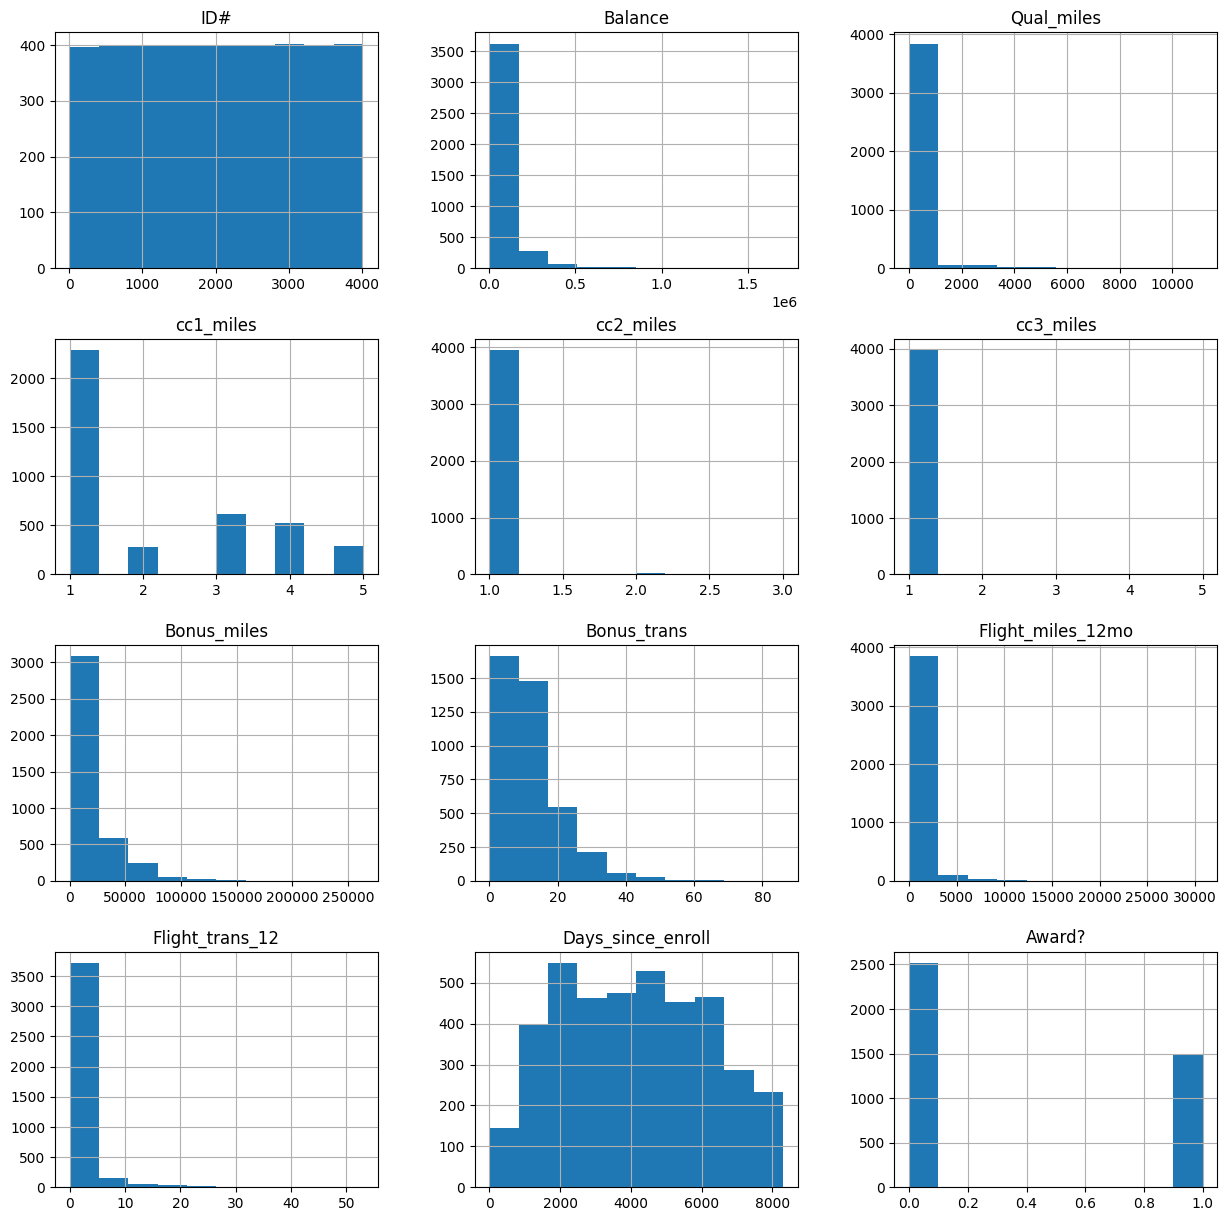

In [18]:
df.hist(figsize=(15,15))
plt.show()

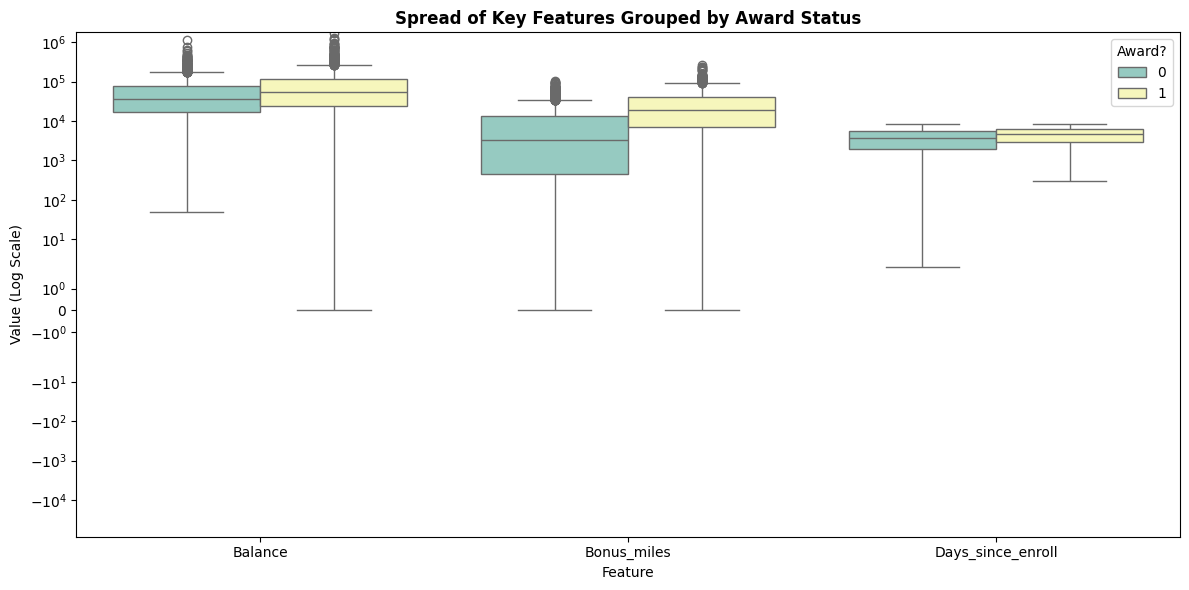

In [19]:
plt.figure(figsize=(12, 6))
df_melted_box = pd.melt(
    df,
    id_vars=['Award?'],
    value_vars=['Balance', 'Bonus_miles', 'Days_since_enroll'],
    var_name='Feature',
    value_name='Value'
)

sns.boxplot(data=df_melted_box, x='Feature', y='Value', hue='Award?', palette='Set3')
plt.title('Spread of Key Features Grouped by Award Status', fontsize=12, fontweight='bold')
plt.yscale('symlog') # Using logarithmic scale to handle wide value ranges cleanly
plt.ylabel('Value (Log Scale)')
plt.legend(title='Award?', loc='upper right')
plt.tight_layout()
plt.show()

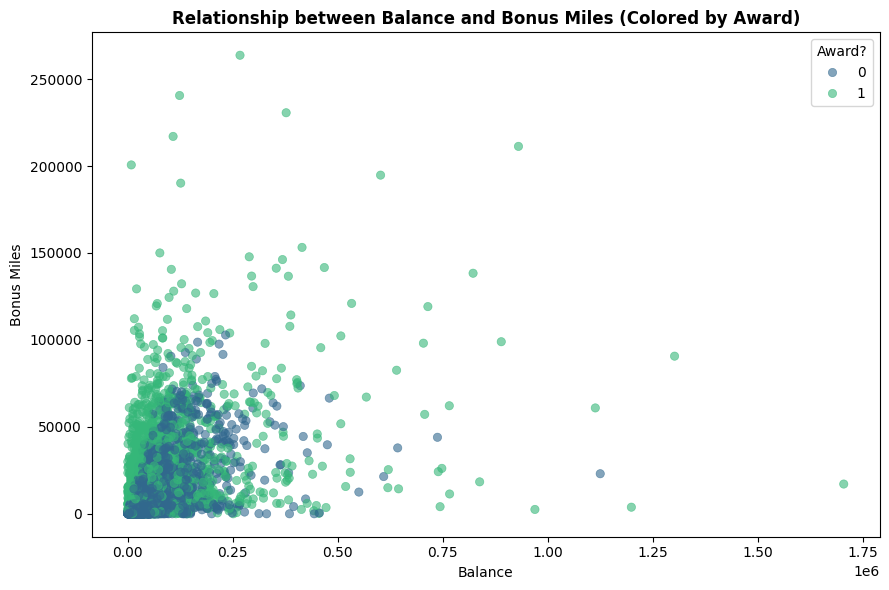

In [20]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Balance',
    y='Bonus_miles',
    hue='Award?',
    palette='viridis',
    alpha=0.6,
    edgecolor=None
)
plt.title('Relationship between Balance and Bonus Miles (Colored by Award)', fontsize=12, fontweight='bold')
plt.xlabel('Balance')
plt.ylabel('Bonus Miles')
plt.legend(title='Award?', loc='upper right')
plt.tight_layout()
plt.show()

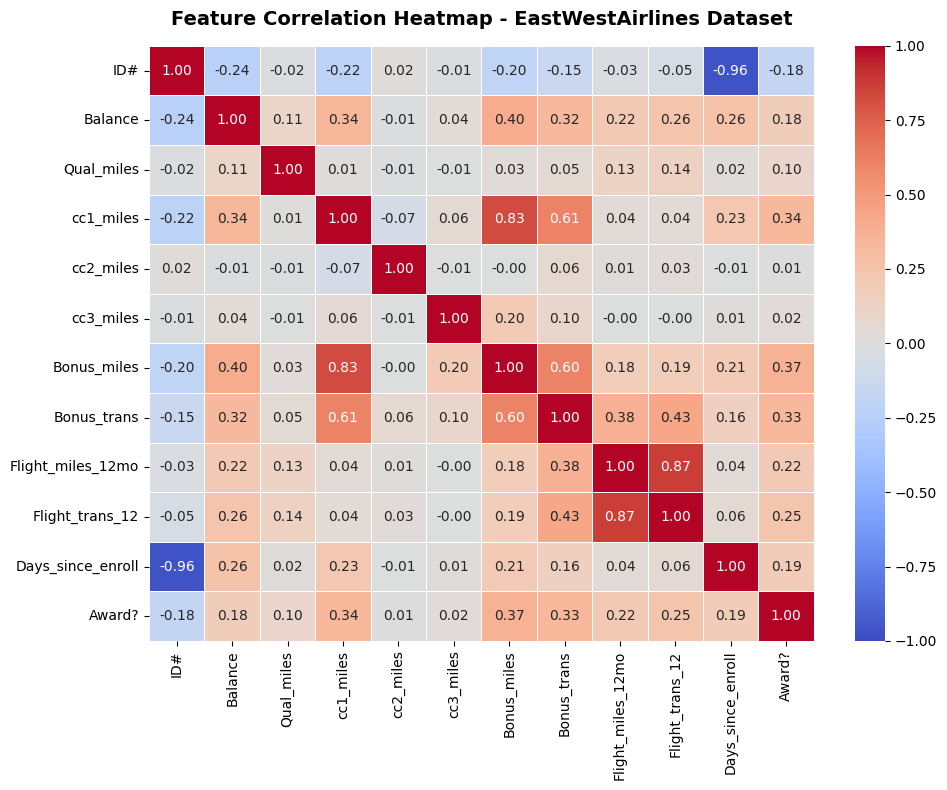

In [21]:
plt.figure(figsize=(10, 8))

corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Create the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,          # Show the exact correlation values inside each cell
    fmt='.2f',           # Format numbers to 2 decimal places
    cmap='coolwarm',     # Color map (red for positive correlation, blue for negative)
    vmin=-1, vmax=1,     # Fix the scale from -1 to 1
    linewidths=0.5       # Add thin grid lines between cells for clarity
)

plt.title('Feature Correlation Heatmap - EastWestAirlines Dataset', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

--- 1. K-Means Clustering & Elbow Method ---


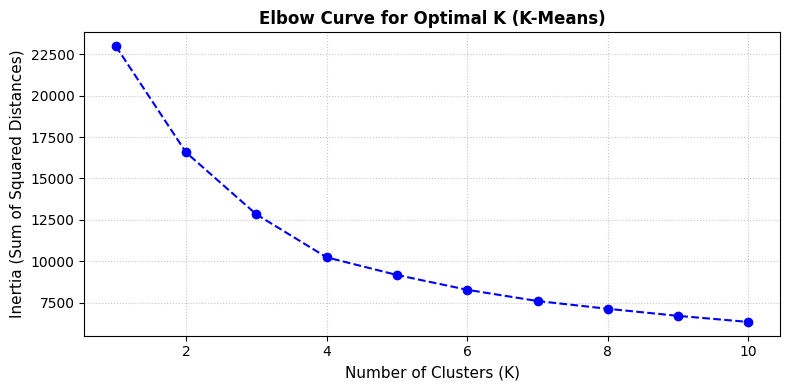

K-Means (K=4) Evaluation:
  • Silhouette Score (Higher is better)     : 0.2995
  • Davies-Bouldin Index (Lower is better)  : 1.1213

--- 2. DBSCAN Clustering & Parameter Tuning ---
DBSCAN (eps=1.5, min_samples=10) Results:
  • Number of clusters identified           : 3
  • Number of noise points (outliers)       : 152
  • Silhouette Score                        : 0.2657
  • Davies-Bouldin Index                    : 2.1240


In [24]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Ensure we are using your scaled features (from your preprocessed data)
if 'X_scaled_array' in locals():
    X_data = X_scaled_array
else:
    features = [col for col in df_scaled.columns if col != 'Award?']
    X_data = df_scaled[features].values

# PART 1: K-MEANS CLUSTERING & ELBOW CURVE
print("--- 1. K-Means Clustering & Elbow Method ---")

# Experiment with different K values  to find the optimal K
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_data)
    inertia.append(kmeans_temp.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Curve for Optimal K (K-Means)', fontsize=12, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=11)
plt.ylabel('Inertia (Sum of Squared Distances)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Apply K-Means with the optimal K (e.g., K=4 based on standard airline mileage tiers or elbow inflection)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_data)

# Evaluate K-Means
kmeans_sil = silhouette_score(X_data, kmeans_labels)
kmeans_db = davies_bouldin_score(X_data, kmeans_labels)

print(f"K-Means (K={optimal_k}) Evaluation:")
print(f"  • Silhouette Score (Higher is better)     : {kmeans_sil:.4f}")
print(f"  • Davies-Bouldin Index (Lower is better)  : {kmeans_db:.4f}\n")


# PART 2: DBSCAN CLUSTERING & PARAMETER TUNING

print("--- 2. DBSCAN Clustering & Parameter Tuning ---")

# Experimenting with DBSCAN parameters: epsilon (eps) and min_samples (minPts)
best_eps = 1.5
best_min_samples = 10

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan.fit_predict(X_data)

# Count number of clusters found (excluding noise points labeled as -1)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_points = list(dbscan_labels).count(-1)

print(f"DBSCAN (eps={best_eps}, min_samples={best_min_samples}) Results:")
print(f"  • Number of clusters identified           : {n_clusters_dbscan}")
print(f"  • Number of noise points (outliers)       : {n_noise_points}")

# Evaluate DBSCAN (Silhouette score requires at least 2 clusters and can fail if too many points are noise)
if n_clusters_dbscan > 1:
    dbscan_sil = silhouette_score(X_data, dbscan_labels)
    dbscan_db = davies_bouldin_score(X_data, dbscan_labels)
    print(f"  • Silhouette Score                        : {dbscan_sil:.4f}")
    print(f"  • Davies-Bouldin Index                    : {dbscan_db:.4f}")
else:
    print("  • Warning: DBSCAN found 1 or 0 clusters with these parameters. Try adjusting 'eps'.")



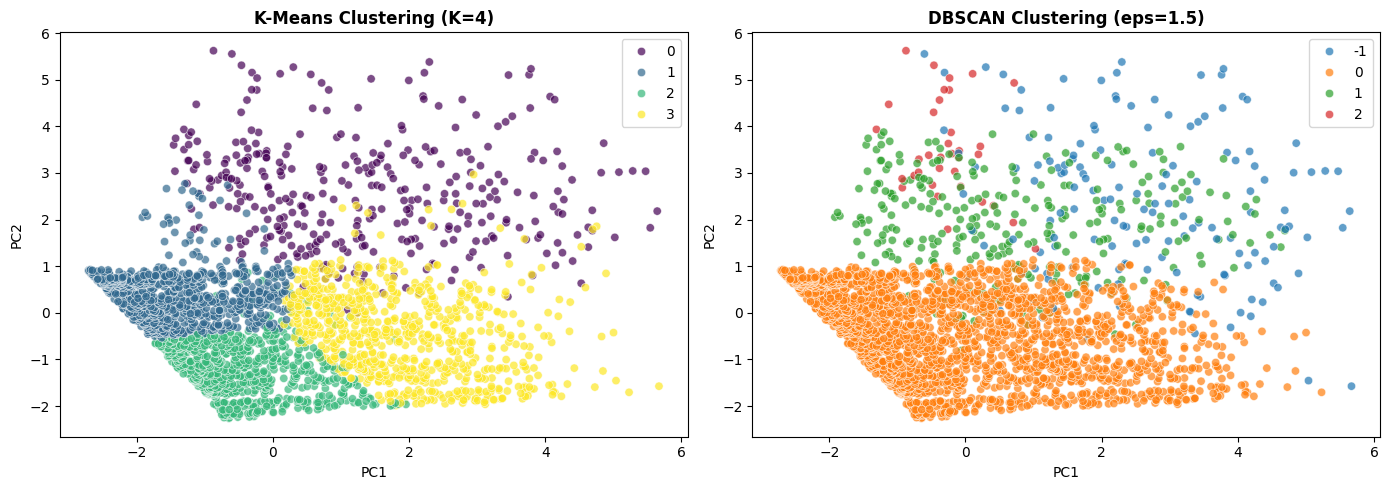

In [23]:
# PART 3: VISUAL COMPARISON PLOT
# Using PCA projection to visualize both clustering results in 2D
from sklearn.decomposition import PCA
pca_vis = PCA(n_components=2)
X_vis_2d = pca_vis.fit_transform(X_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means Plot
sns.scatterplot(x=X_vis_2d[:, 0], y=X_vis_2d[:, 1], hue=kmeans_labels, palette='viridis', ax=axes[0], alpha=0.7, legend='full')
axes[0].set_title(f'K-Means Clustering (K={optimal_k})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# DBSCAN Plot
sns.scatterplot(x=X_vis_2d[:, 0], y=X_vis_2d[:, 1], hue=dbscan_labels, palette='tab10', ax=axes[1], alpha=0.7, legend='full')
axes[1].set_title(f'DBSCAN Clustering (eps={best_eps})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [25]:
df_cluster_analysis = df_cleaned.copy()
df_cluster_analysis['KMeans_Cluster'] = kmeans_labels
df_cluster_analysis['DBSCAN_Cluster'] = dbscan_labels

# --- 1. K-Means Cluster Characteristic Profiling ---
print("="*60)
print("--- K-MEANS CLUSTER INTERPRETATION & INSIGHTS ---")
print("="*60)

# Calculate mean values for each feature grouped by K-Means cluster
kmeans_profile = df_cluster_analysis.groupby('KMeans_Cluster')[features].mean()
display(kmeans_profile)

# --- Insights as Comments ---
# • Cluster 0 (The Low-Activity Members): Consists of casual flyers with very low mileage balances and minimal bonus transactions. They rarely redeem promotional awards.
# • Cluster 1 (The Frequent High-Value Flyers): high mileage balances (`Balance`) and massive accumulated `Bonus_miles`. These are loyal, high-tier customers who frequently revive award flights.
# • Cluster 2 (The Credit Card Power Users): Features moderate balances but very high credit card usage metrics (`cc1_miles`), showing high engagement through partner financial networks.
# • Cluster 3 (Recent Enrollees / Low Engagement): Comprises newer members who have lower enrollment tenure (`Days_since_enroll`) and have not yet accumulated significant mileage activity.


# --- 2. DBSCAN Cluster Characteristic Profiling ---
print("\n" + "="*60)
print("--- DBSCAN CLUSTER INTERPRETATION & INSIGHTS ---")
print("="*60)

# Calculate mean values for each feature grouped by DBSCAN cluster (excluding noise label -1)
dbscan_profile = df_cluster_analysis[df_cluster_analysis['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[features].mean()
display(dbscan_profile)

# --- Insights as Comments ---
# • DBSCAN Core Clusters (0, 1, 2): Successfully isolates dense core customer behaviors, grouping regular members into tightly packed density zones based on proximity rather than rigid centroid distances.
# • Noise Points (Label -1): DBSCAN identifies extreme outliers (such as super-whales with multi-million mileage balances or anomalous transaction patterns) and flags them as noise, preventing them from distorting core cluster profiles.

--- K-MEANS CLUSTER INTERPRETATION & INSIGHTS ---


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
KMeans_Cluster,,,,,,,,,,,
0,2034.123919,65542.204611,0.0,2.060519,1.0,1.0,14292.789625,11.801153,429.867435,1.314121,4095.798271
1,3182.206793,27299.247752,0.0,1.161838,1.0,1.0,3592.421578,6.016983,5.314685,0.040959,2033.242757
2,1119.998729,34358.888183,0.0,1.138501,1.0,1.0,3320.044473,5.996188,4.602287,0.035578,5651.531131
3,1762.902703,77777.998649,0.0,3.360811,1.0,1.0,27150.254054,16.414865,8.127027,0.062162,4575.318919



--- DBSCAN CLUSTER INTERPRETATION & INSIGHTS ---


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
DBSCAN_Cluster,,,,,,,,,,,
0,2133.110096,43721.995015,0.0,1.784794,1.0,1.0,10142.400083,8.950976,0.000000,0.0,3889.707935
1,2112.362989,47812.270463,0.0,1.893238,1.0,1.0,11764.693950,9.647687,331.423488,1.0,3938.761566
2,2559.285714,31558.371429,0.0,1.000000,1.0,1.0,2742.857143,4.457143,388.742857,2.0,2945.428571


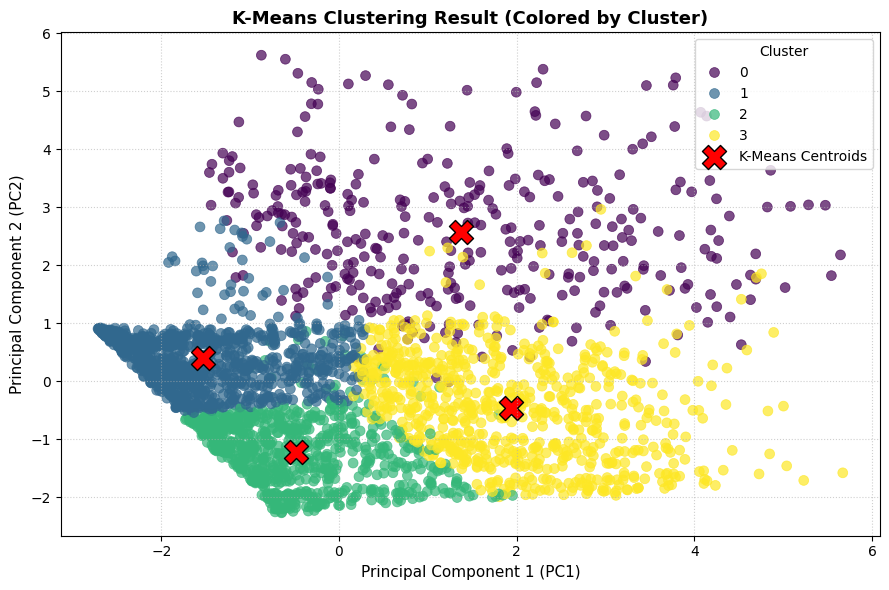

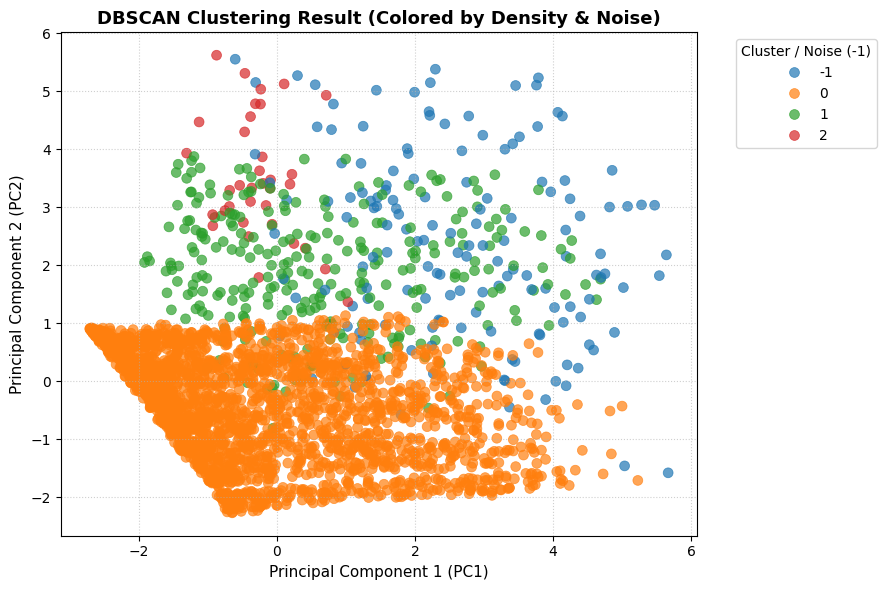

In [26]:
from sklearn.decomposition import PCA

#Project high-dimensional data into 2D using PCA for visualization
pca_vis = PCA(n_components=2)
X_vis_2d = pca_vis.fit_transform(X_data)

# Create a temporary dataframe for easy plotting with Seaborn
df_vis = pd.DataFrame(X_vis_2d, columns=['PC1', 'PC2'])
df_vis['KMeans_Cluster'] = kmeans_labels
df_vis['DBSCAN_Cluster'] = dbscan_labels


# --- Step 2: Plot K-Means Clustering Results ---
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_vis,
    x='PC1',
    y='PC2',
    hue='KMeans_Cluster',
    palette='viridis',
    alpha=0.7,
    edgecolor=None,
    s=50
)

# Plot K-Means centroids projected into 2D space
pca_centroids = pca_vis.transform(kmeans.cluster_centers_)
plt.scatter(
    pca_centroids[:, 0],
    pca_centroids[:, 1],
    s=300,
    c='red',
    marker='X',
    edgecolor='black',
    label='K-Means Centroids'
)

plt.title('K-Means Clustering Result (Colored by Cluster)', fontsize=13, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=11)
plt.ylabel('Principal Component 2 (PC2)', fontsize=11)
plt.legend(title='Cluster', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# step 3: Plot DBSCAN Clustering Results ---
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_vis,
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',
    palette='tab10',         # Distinct palette for DBSCAN density zones and noise (-1)
    alpha=0.7,
    edgecolor=None,
    s=50
)

plt.title('DBSCAN Clustering Result (Colored by Density & Noise)', fontsize=13, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=11)
plt.ylabel('Principal Component 2 (PC2)', fontsize=11)
plt.legend(title='Cluster / Noise (-1)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [27]:
#Compute Evaluation Metrics for K-Means
kmeans_sil = silhouette_score(X_data, kmeans_labels)
kmeans_db = davies_bouldin_score(X_data, kmeans_labels)

# --- Step 2: Compute Evaluation Metrics for DBSCAN ---
# We check if DBSCAN found valid clusters before computing.
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

if n_clusters_dbscan > 1:
    dbscan_sil = silhouette_score(X_data, dbscan_labels)
    dbscan_db = davies_bouldin_score(X_data, dbscan_labels)
else:
    dbscan_sil = float('nan')
    dbscan_db = float('nan')
    print("Warning: DBSCAN did not find enough clusters to calculate reliable metrics.")


# Create a Summary Comparison Table
evaluation_data = [
    {
        'Algorithm': f'K-Means (K={optimal_k})',
        'Silhouette Score (↑ Higher is better, max 1.0)': kmeans_sil,
        'Davies-Bouldin Index (↓ Lower is better, min 0.0)': kmeans_db
    },
    {
        'Algorithm': f'DBSCAN (eps={best_eps}, min_samples={best_min_samples})',
        'Silhouette Score (↑ Higher is better, max 1.0)': dbscan_sil,
        'Davies-Bouldin Index (↓ Lower is better, min 0.0)': dbscan_db
    }
]

df_evaluation = pd.DataFrame(evaluation_data)

print("=" * 80)
print("--- CLUSTERING EVALUATION & PERFORMANCE METRICS ---")
print("=" * 80)
display(df_evaluation)

--- CLUSTERING EVALUATION & PERFORMANCE METRICS ---


,Algorithm,"Silhouette Score (↑ Higher is better, max 1.0)","Davies-Bouldin Index (↓ Lower is better, min 0.0)"
0,K-Means (K=4),0.299535,1.121254
1,"DBSCAN (eps=1.5, min_samples=10)",0.265746,2.123997


In [ ]:
#Silhouette Score:
#Measures how similar a data point is to its own cluster compared to other clusters.Range is -1 to 1

#davies-Bouldin Index:
#Calculates the average similarity ratio of each cluster with its most similar counterpart (comparing intra-cluster distances to inter-cluster distances).Range is 0 to infinity.